# Exact sampling from fair bits

This notebook reproduces and illustrates every numerical result reported in the manuscript.
Nothing is hard-coded: each figure and table is recomputed from the samplers themselves.

**Contents**

1. Setup and output directory
2. Case A — exact uniform sampling from fair bits
3. Case B — exact weighted sampling from fair bits
4. The level-width identity that makes the exact tree representable
5. The entropy band
6. Summary table and figure export

Case A's target was named before generation; Case B's was not. The notebook reproduces the
mathematics of both. It does not, and cannot, reproduce the generation events themselves.


In [1]:
PROJECT_NAME = "exact-sampling-from-fair-bits"

import os, sys, math, random, itertools, json
from fractions import Fraction

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    OUTPUT_DIR = f"/content/drive/MyDrive/Outputs/{PROJECT_NAME}"
except Exception:
    OUTPUT_DIR = os.path.join(os.getcwd(), "Outputs", PROJECT_NAME)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Outputs ->", OUTPUT_DIR)

Outputs -> /home/claude/repo/exact-sampling-from-fair-bits/notebook/Outputs/exact-sampling-from-fair-bits


## 1. Case A — exact uniform sampling

Keep a range size `v` and a value `c` uniform within it. Each fresh bit doubles the range.
When the range reaches `n`, accept the first `n` values; otherwise subtract `n` from both,
which retains the information in the rejected draw instead of discarding it.

In [2]:
def sample_uniform(n, flip):
    if not isinstance(n, int) or isinstance(n, bool) or n < 1:
        raise ValueError("n must be a positive integer")
    if n == 1:
        return 0
    v, c = 1, 0
    while True:
        v, c = 2 * v, 2 * c + flip()
        if v >= n:
            if c < n:
                return c
            v, c = v - n, c - n


def expected_bits_uniform(n):
    """Exact E[T] = sum_k (2^k mod n)/2^k, summed over transient + cycle."""
    r, k, tot, seen = 1 % n, 0, Fraction(0), {}
    while r and r not in seen:
        seen[r] = (k, tot)
        tot += Fraction(r, 2 ** k)
        r, k = (2 * r) % n, k + 1
    if not r:
        return tot
    start, prefix = seen[r]
    return prefix + (tot - prefix) / (1 - Fraction(1, 2 ** (k - start)))


def baseline_bits(n):
    m = (n - 1).bit_length()
    return Fraction(m * 2 ** m, n)

print("n=6 :", expected_bits_uniform(6), "vs restart", baseline_bits(6))
print("n=10:", expected_bits_uniform(10), "vs restart", baseline_bits(10))

n=6 : 11/3 vs restart 4
n=10: 23/5 vs restart 32/5


### Exhaustive check

Every bit string of length 12 is fed to the sampler for each `n` from 1 to 32 — 131,072 executions.
Each output must occur exactly `floor(4096/n)` times, and exactly `4096 mod n` strings must remain
unfinished. An unfinished string is not an error: the sampler is entitled to ask for more bits.

In [3]:
def verify_uniform(n, depth=12):
    counts, unfinished = [0] * n, 0
    for bits in itertools.product((0, 1), repeat=depth):
        it = iter(bits)
        try:
            counts[sample_uniform(n, lambda: next(it))] += 1
        except StopIteration:
            unfinished += 1
    assert counts == [(2 ** depth) // n] * n, (n, counts)
    assert unfinished == (2 ** depth) % n, (n, unfinished)
    return 2 ** depth

total = sum(verify_uniform(n) for n in range(1, 33))
print(f"{total:,} executions checked across n = 1..32 — all exact")

131,072 executions checked across n = 1..32 — all exact


## 2. Case B — exact weighted sampling

Expand each target probability `w_i/W` in binary by integer long division, keeping only the
residues `r_i = 2^k w_i mod W`. Those residues define a generating tree implicitly: at level `k`
the indices whose `k`-th binary digit is 1 become leaves, and the rest of the level stays internal.

In [4]:
class ExactWeightedSampler:
    def __init__(self, weights):
        w = [int(x) for x in weights]
        if any(x < 0 for x in w):
            raise ValueError("weights must be non-negative")
        W = sum(w)
        if W <= 0:
            raise ValueError("weights must not be all zero")
        self.w, self.W, self.n = w, W, len(w)
        support = [i for i, x in enumerate(w) if x > 0]
        self.degenerate = support[0] if len(support) == 1 else None
        self._r, self._m, self._levels = list(w), 1, []

    @staticmethod
    def _advance(r, m, W, n):
        leaves = []
        for i in range(n):
            t = r[i] << 1
            if t >= W:
                t -= W
                leaves.append(i)
            r[i] = t
        return leaves, (m << 1) - len(leaves)

    def level(self, k):
        while len(self._levels) < k:
            leaves, self._m = self._advance(self._r, self._m, self.W, self.n)
            self._levels.append((leaves, self._m))
        return self._levels[k - 1]

    def sample(self, flip):
        if self.degenerate is not None:
            return self.degenerate          # zero bits
        j, k = 0, 0
        while True:
            k += 1
            j = (j << 1) | flip()
            leaves, m_k = self.level(k)
            if j >= m_k:
                return leaves[j - m_k]

    def expected_bits(self, depth=400):
        if self.degenerate is not None:
            return Fraction(0)
        r, m, tot = list(self.w), 1, Fraction(1)
        for k in range(1, depth + 1):
            _, m = self._advance(r, m, self.W, self.n)
            tot += Fraction(m, 1 << k)
        return tot

s = ExactWeightedSampler([1, 2, 3])
print("E[bits] for (1,2,3):", float(s.expected_bits()))

E[bits] for (1,2,3): 2.0


In [5]:
def verify_weighted(weights, depth):
    s = ExactWeightedSampler(weights)
    counts, unfinished, W = {}, 0, sum(weights)
    for bits in itertools.product((0, 1), repeat=depth):
        it = iter(bits)
        try:
            out = s.sample(lambda: next(it))
        except StopIteration:
            unfinished += 1
            continue
        counts[out] = counts.get(out, 0) + 1
    row = [counts.get(i, 0) for i in range(len(weights))]
    expected = [((1 << depth) * w) // W for w in weights]
    assert row == expected, (weights, row, expected)
    assert sum(row) + unfinished == (1 << depth)
    return row, unfinished

for weights, d in [([1,2,3],14), ([3,5],12), ([1,1,1],12), ([0,3,0,5,0],12), ([2,7,11,4],13)]:
    row, unf = verify_weighted(weights, d)
    print(f"{str(weights):<16} depth {d}: {row}  unfinished={unf}  total={sum(row)+unf}")

[1, 2, 3]        depth 14: [2730, 5461, 8192]  unfinished=1  total=16384
[3, 5]           depth 12: [1536, 2560]  unfinished=0  total=4096
[1, 1, 1]        depth 12: [1365, 1365, 1365]  unfinished=1  total=4096
[0, 3, 0, 5, 0]  depth 12: [0, 1536, 0, 2560, 0]  unfinished=0  total=4096
[2, 7, 11, 4]    depth 13: [682, 2389, 3754, 1365]  unfinished=2  total=8192


## 3. The level-width identity

The construction is only implementable because the tree never gets wide. Summing the level
recursion gives

$$m_k \;=\; \frac{1}{W}\sum_i \left(2^k w_i \bmod W\right) \;\le\; n-1 .$$

The leaf count of the full tree is proportional to `W`, but nothing that must be stored is:
`n` residues suffice. The cell below recomputes `m_k` from the closed form and compares it with
the sampler, over 300 random weight vectors and 24 levels each.

In [6]:
def m_k_closed_form(weights, k):
    W = sum(weights)
    total = sum((w * (1 << k)) % W for w in weights)
    assert total % W == 0
    return total // W

random.seed(11)
comparisons, worst = 0, -10**9
for _ in range(300):
    n = random.randint(2, 7)
    w = [random.randint(0, 10 ** random.randint(1, 8)) for _ in range(n)]
    if sum(w) == 0:
        continue
    s = ExactWeightedSampler(w)
    if s.degenerate is not None:
        continue
    for k in range(1, 25):
        direct, from_sampler = m_k_closed_form(w, k), s.level(k)[1]
        assert direct == from_sampler
        assert direct <= n - 1
        worst = max(worst, direct - (n - 1))
        comparisons += 1

print(f"{comparisons:,} comparisons: closed form matches the sampler everywhere")
print(f"max(m_k - (n-1)) = {worst}   (0 means the bound is attained, never exceeded)")

7,200 comparisons: closed form matches the sampler everywhere
max(m_k - (n-1)) = 0   (0 means the bound is attained, never exceeded)


## 4. The entropy band

The expected number of fair bits sits between the Shannon entropy and entropy plus two.
The lower bound is information-theoretic; the upper bound is the classical one for exact
generating trees. The near-degenerate vectors are the interesting ones: they push the gap
towards exactly 2, which is where the bound is tight.

In [7]:
def entropy(weights):
    W = sum(weights)
    return -sum((w / W) * math.log2(w / W) for w in weights if w > 0)

random.seed(4)
Hs, Es = [], []
for _ in range(400):
    n = random.randint(2, 8)
    w = [random.randint(0, 10 ** random.randint(1, 6)) for _ in range(n)]
    if sum(w) == 0 or sum(1 for x in w if x > 0) < 2:
        continue
    s = ExactWeightedSampler(w)
    Hs.append(entropy(w))
    Es.append(float(s.expected_bits()))

gaps = [e - h for e, h in zip(Es, Hs)]
print(f"vectors: {len(Hs)}")
print(f"violations of E >= H   : {sum(1 for g in gaps if g < -1e-9)}")
print(f"violations of E <= H+2 : {sum(1 for g in gaps if g > 2 + 1e-9)}")
print(f"largest gap observed   : {max(gaps):.6f}")

adv = [1, 10 ** 12]
s = ExactWeightedSampler(adv)
print(f"adversarial {adv}: E = {float(s.expected_bits(600)):.6f}, H = {entropy(adv):.3e}")

vectors: 399
violations of E >= H   : 0
violations of E <= H+2 : 0
largest gap observed   : 1.999892
adversarial [1, 1000000000000]: E = 2.000000, H = 4.131e-11


## 5. Figures

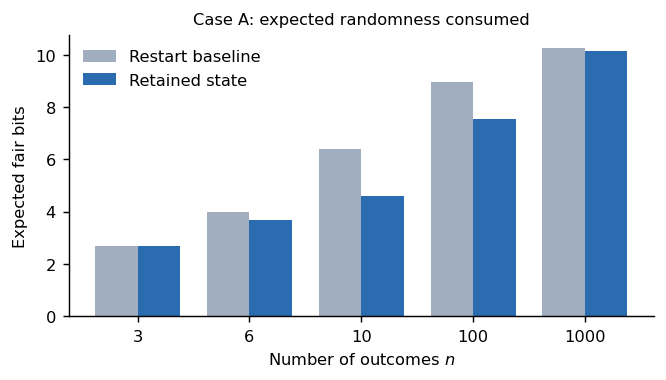

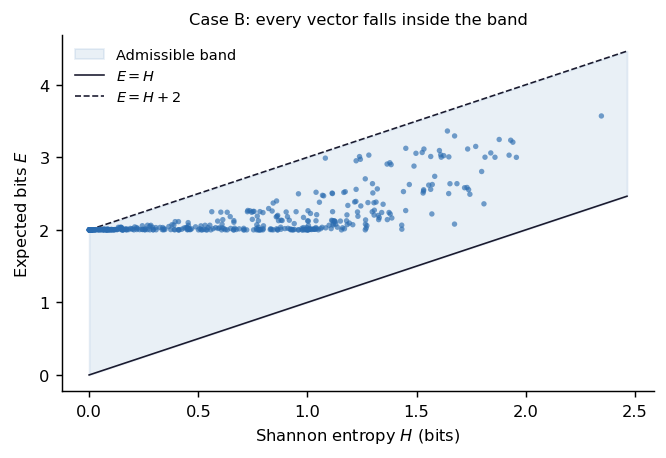

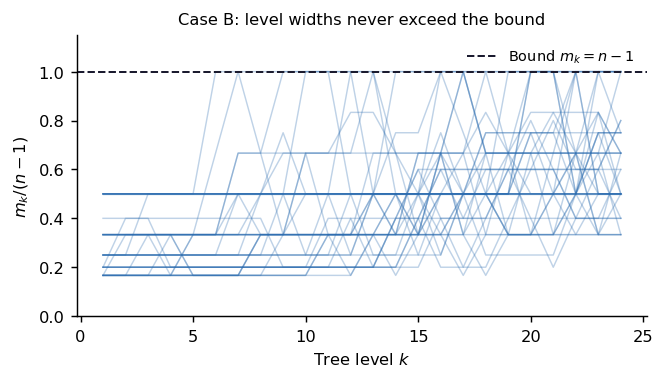

In [8]:
import matplotlib
import matplotlib.pyplot as plt

INK, ACC, MUT = "#1a1a2e", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"font.size": 9, "figure.dpi": 130})

# --- Case A: bits per output
ns = [3, 6, 10, 100, 1000]
base = [float(baseline_bits(n)) for n in ns]
cand = [float(expected_bits_uniform(n)) for n in ns]
fig, ax = plt.subplots(figsize=(5.2, 3.0))
x = range(len(ns)); w = 0.38
ax.bar([i - w/2 for i in x], base, w, label="Restart baseline", color=MUT)
ax.bar([i + w/2 for i in x], cand, w, label="Retained state", color=ACC)
ax.set_xticks(list(x)); ax.set_xticklabels([str(n) for n in ns])
ax.set_xlabel("Number of outcomes $n$"); ax.set_ylabel("Expected fair bits")
ax.set_title("Case A: expected randomness consumed", fontsize=9)
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(f"{OUTPUT_DIR}/fig_caseA_bits.png", dpi=200); plt.show()

# --- Case B: entropy band
fig, ax = plt.subplots(figsize=(5.2, 3.6))
lo, hi = 0, max(Hs) * 1.05
ax.fill_between([lo, hi], [lo, hi], [lo + 2, hi + 2], color=ACC, alpha=0.10,
                label="Admissible band")
ax.plot([lo, hi], [lo, hi], color=INK, lw=0.9, label="$E = H$")
ax.plot([lo, hi], [lo + 2, hi + 2], color=INK, lw=0.9, ls="--", label="$E = H+2$")
ax.scatter(Hs, Es, s=9, color=ACC, alpha=0.65, edgecolors="none", zorder=3)
ax.set_xlabel("Shannon entropy $H$ (bits)"); ax.set_ylabel("Expected bits $E$")
ax.set_title("Case B: every vector falls inside the band", fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(f"{OUTPUT_DIR}/fig_caseB_entropy.png", dpi=200); plt.show()

# --- Case B: level widths
fig, ax = plt.subplots(figsize=(5.2, 3.0))
random.seed(11); shown = 0
for _ in range(400):
    if shown >= 40:
        break
    n = random.randint(3, 7)
    w_ = [random.randint(1, 10 ** random.randint(1, 8)) for _ in range(n)]
    s_ = ExactWeightedSampler(w_)
    if s_.degenerate is not None:
        continue
    ks = list(range(1, 25))
    ax.plot(ks, [s_.level(k)[1] / (n - 1) for k in ks], color=ACC, alpha=0.30, lw=0.8)
    shown += 1
ax.axhline(1.0, color=INK, lw=1.1, ls="--", label="Bound $m_k = n-1$")
ax.set_ylim(0, 1.15); ax.set_xlabel("Tree level $k$"); ax.set_ylabel("$m_k / (n-1)$")
ax.set_title("Case B: level widths never exceed the bound", fontsize=9)
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(f"{OUTPUT_DIR}/fig_caseB_width.png", dpi=200); plt.show()

## 6. Summary

In [9]:
summary = {
    "case_A": {
        "exhaustive_executions": total,
        "expected_bits": {str(n): str(expected_bits_uniform(n)) for n in ns},
        "restart_baseline": {str(n): str(baseline_bits(n)) for n in ns},
        "blinded": False,
    },
    "case_B": {
        "level_width_comparisons": comparisons,
        "max_excess_over_bound": worst,
        "entropy_vectors": len(Hs),
        "largest_gap": max(gaps),
        "blinded": True,
    },
}
with open(f"{OUTPUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\nSaved to", OUTPUT_DIR)

{
  "case_A": {
    "exhaustive_executions": 131072,
    "expected_bits": {
      "3": "8/3",
      "6": "11/3",
      "10": "23/5",
      "100": "1548/205",
      "1000": "457172427661853/45035996273705"
    },
    "restart_baseline": {
      "3": "8/3",
      "6": "4",
      "10": "32/5",
      "100": "224/25",
      "1000": "256/25"
    },
    "blinded": false
  },
  "case_B": {
    "level_width_comparisons": 7200,
    "max_excess_over_bound": 0,
    "entropy_vectors": 399,
    "largest_gap": 1.9998916894958918,
    "blinded": true
  }
}

Saved to /home/claude/repo/exact-sampling-from-fair-bits/notebook/Outputs/exact-sampling-from-fair-bits


---

**What these results establish.** Both cases are derivable from premises published before 2010
without being explicitly recorded in them. Case B additionally had its target absent from the
generating context. Neither case establishes independent rediscovery: the models' parameters were
never restricted, and that limitation cannot be removed by any check in this notebook.